# Chapter 9: Integral Curves and Flows

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `205-248`.
Source-map focus: integral curves, flows, flowouts, manifolds with boundary, Lie derivatives, commuting fields, time-dependent fields, and first-order PDEs.
I inspected the PDF text for this span with `pdftotext`; in this file the corresponding PDF pages are `223-266`.

**Chapter Goal.** Turn a smooth vector field into the geometric data it controls: its integral curves, its maximal flow domain, the local coordinates built by flowing out from a hypersurface, and the characteristic curves that solve first-order Cauchy problems.

The chapter is an ODE laboratory inside manifold language. A vector field gives a first-order system in every chart. Local existence and uniqueness give short integral curves. Maximality tells us how far the curves can run. The flow law then packages all starting points into partially defined diffeomorphisms. The rest of the chapter asks what those diffeomorphisms do to submanifolds, boundaries, other vector fields, time-dependent equations, and PDE initial data.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import networkx as nx
import numpy as np
import sympy as sp
import plotly.graph_objects as go
from IPython.display import Markdown, display

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    ensure_parent,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-09-integral-curves-and-flows"
UNIT_TITLE = "Integral Curves and Flows"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
GENERATED_ARTIFACTS = []
CHECK_RESULTS = {}

plt.rcParams.update({
    "figure.dpi": 125,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

def remember(path):
    GENERATED_ARTIFACTS.append(Path(path))
    return path

def save_plotly_self_contained(fig, path):
    path = ensure_parent(Path(path))
    fig.write_html(str(path), include_plotlyjs=True, full_html=True)
    return path

def quiver_field(ax, xs, ys, field, *, color="#4b5563", alpha=0.75, scale=24):
    X, Y = np.meshgrid(xs, ys)
    U, V = field(X, Y)
    speed = np.hypot(U, V)
    U = np.divide(U, speed, out=np.zeros_like(U), where=speed > 1e-12)
    V = np.divide(V, speed, out=np.zeros_like(V), where=speed > 1e-12)
    ax.quiver(X, Y, U, V, angles="xy", scale_units="xy", scale=scale, color=color, alpha=alpha, width=0.004)

def bracket_components(V, W):
    x, y = sp.symbols("x y", real=True)
    Vx, Vy = V
    Wx, Wy = W
    return sp.Matrix([
        sp.simplify(Vx * sp.diff(Wx, x) + Vy * sp.diff(Wx, y) - Wx * sp.diff(Vx, x) - Wy * sp.diff(Vx, y)),
        sp.simplify(Vx * sp.diff(Wy, x) + Vy * sp.diff(Wy, y) - Wx * sp.diff(Vy, x) - Wy * sp.diff(Vy, y)),
    ])

display(Markdown(f"Artifacts will be written under `{ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix()}/`."))


Artifacts will be written under `artifacts/chapter-09-integral-curves-and-flows/`.

## Visual Storyboard

**Chapter implementation brief.**

| Sequence | Concept | Representation | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| 1 | Integral curves | Two explicit vector fields on the plane | Velocity agrees with the displayed field at every time | Symbolic residuals vanish |
| 2 | Maximal flows and flow domains | Blow-up and punctured-plane escape pictures | The flow can be smooth and still fail to exist for all time | Flow law and shifted interval checks |
| 3 | Flowouts and canonical form | Flowout from a hypersurface under a rotation field | Flow parameters become local coordinates where the field is `partial_t` | Jacobian and pushforward checks |
| 4 | Boundary behavior | Half-plane models for tangent, inward, and outward fields | Which hypotheses keep curves inside a manifold with boundary | Normal component signs |
| 5 | Lie derivatives | Push-forward/pull-back comparison along a flow | Why vector fields must be compared in one tangent space | Finite difference equals Lie bracket |
| 6 | Commuting fields | Flow squares that close or fail to close | `flow_V flow_W = flow_W flow_V` exactly when the bracket vanishes | Endpoint gap and bracket residual |
| 7 | Time-dependent fields | Scaling flow with starting time parameter | The flow has two time arguments and a cocycle law | Composition residual |
| 8 | First-order PDE characteristics | Linear and quasilinear characteristic flowouts | A Cauchy problem becomes ODEs along curves | PDE residuals and noncharacteristic tests |

**Proof visualization strategy.** The dependency graph below records the proof route: local ODE theory feeds the fundamental theorem on flows; flowout gives canonical coordinates and boundary collars; Lie derivative connects flows to brackets; the flowout viewpoint becomes the method of characteristics for first-order PDEs.


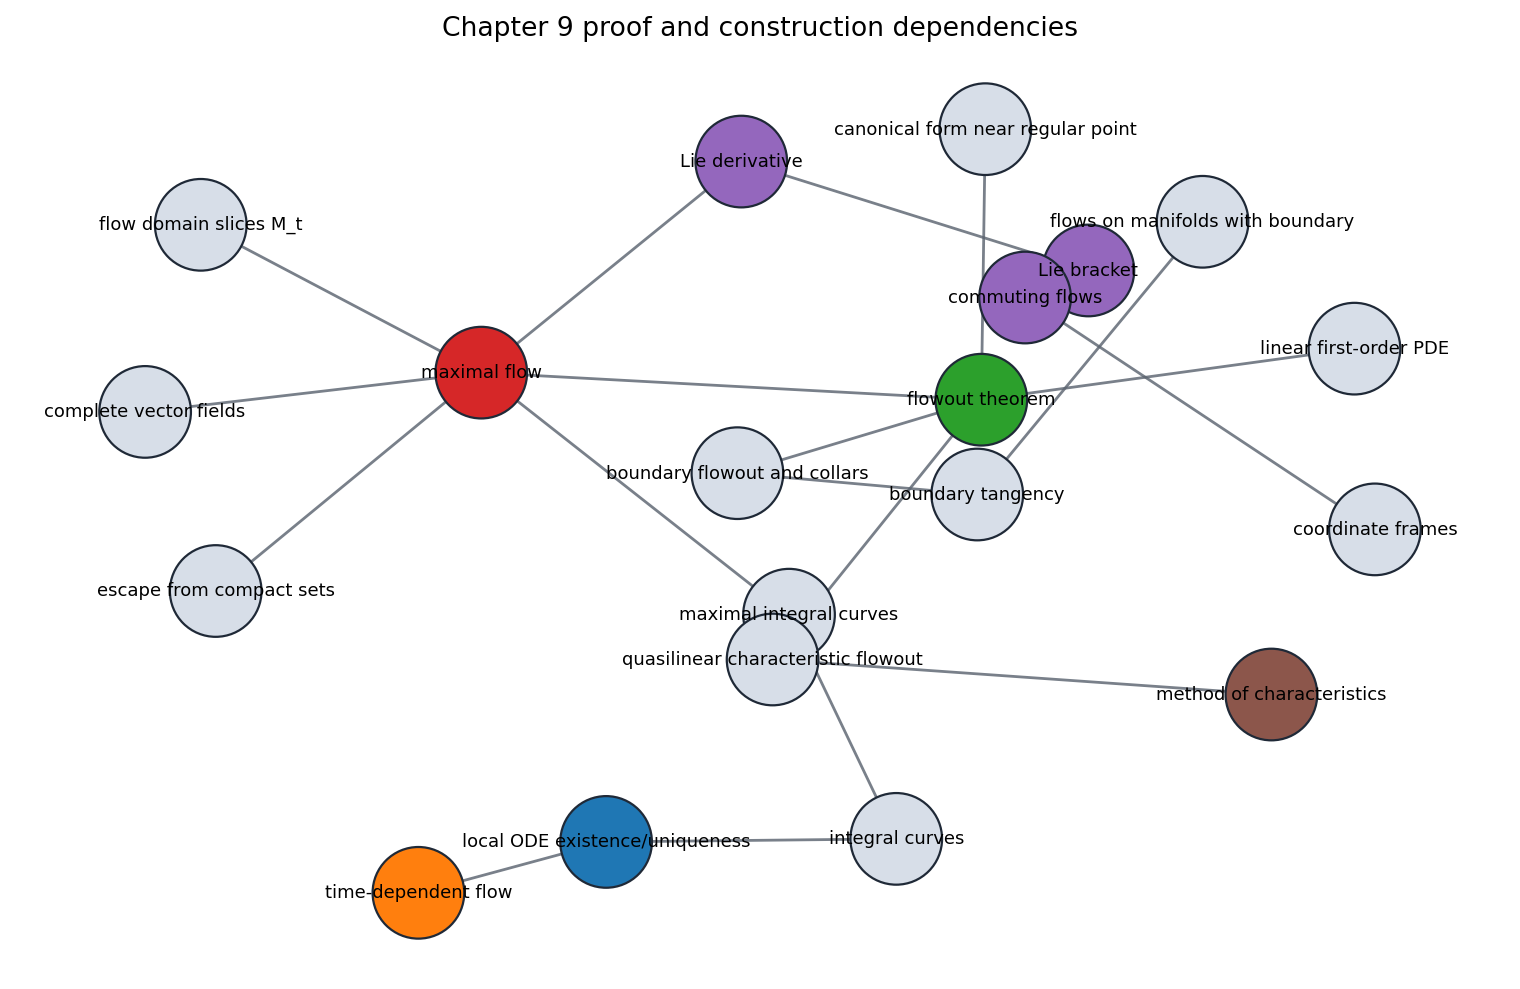

In [2]:
dependency_edges = [
    ("local ODE existence/uniqueness", "integral curves"),
    ("integral curves", "maximal integral curves"),
    ("maximal integral curves", "maximal flow"),
    ("maximal flow", "flow domain slices M_t"),
    ("maximal flow", "complete vector fields"),
    ("maximal flow", "escape from compact sets"),
    ("maximal flow", "flowout theorem"),
    ("flowout theorem", "canonical form near regular point"),
    ("flowout theorem", "boundary flowout and collars"),
    ("boundary flowout and collars", "boundary tangency"),
    ("boundary tangency", "flows on manifolds with boundary"),
    ("maximal flow", "Lie derivative"),
    ("Lie derivative", "Lie bracket"),
    ("Lie bracket", "commuting flows"),
    ("commuting flows", "coordinate frames"),
    ("local ODE existence/uniqueness", "time-dependent flow"),
    ("flowout theorem", "linear first-order PDE"),
    ("flowout theorem", "quasilinear characteristic flowout"),
    ("quasilinear characteristic flowout", "method of characteristics"),
]
G = nx.DiGraph()
G.add_edges_from(dependency_edges)
role_color = {
    "local ODE existence/uniqueness": "#1f77b4",
    "maximal flow": "#d62728",
    "flowout theorem": "#2ca02c",
    "Lie derivative": "#9467bd",
    "Lie bracket": "#9467bd",
    "commuting flows": "#9467bd",
    "time-dependent flow": "#ff7f0e",
    "method of characteristics": "#8c564b",
}
pos = nx.spring_layout(G, seed=907, k=0.75)
fig, ax = plt.subplots(figsize=(12, 7.5))
colors = [role_color.get(node, "#d7dee8") for node in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.25, edge_color="#5b6470", alpha=0.82)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1700, linewidths=1, edgecolors="#1f2937")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.1)
ax.set_title("Chapter 9 proof and construction dependencies")
ax.axis("off")
dependency_path = remember(save_matplotlib(fig, FIGURES / "chapter-09-flow-dependency-graph.png"))
plt.close(fig)
dependency_check = remember(save_json(
    {
        "nodes": sorted(G.nodes),
        "edges": dependency_edges,
        "is_weakly_connected": nx.is_weakly_connected(G),
        "source_span": "printed pages 205-248; PDF pages 223-266",
    },
    CHECKS / "chapter-09-flow-dependency-graph.json",
))
CHECK_RESULTS["dependency_graph_connected"] = nx.is_weakly_connected(G)
display_artifact(dependency_path, width=900)


## Library Routing

The chapter is mostly two-dimensional and ODE-driven, so durable Matplotlib figures and exact SymPy residuals are the right default. NetworkX is used only for the proof-dependency map. Plotly is reserved for one genuinely three-dimensional object: the quasilinear characteristic flowout in `(x, y, z)` space.


In [3]:
routing_rows = [
    {
        "concept": "integral curves and planar flows",
        "representation": "streamlines, trajectories, and residual table",
        "library": "Matplotlib + SymPy",
        "why": "2D vector fields and exact ODE residuals are inspectable without a heavier manifold package",
        "artifact": "figures/integral-curves-translation-rotation.png",
    },
    {
        "concept": "maximal flow domains",
        "representation": "domain mask, blow-up curves, and escape-to-hole model",
        "library": "Matplotlib + SymPy",
        "why": "the domain is an inequality in (time, starting point), and the flow law is symbolic",
        "artifact": "figures/maximal-flow-domains-and-escape.png",
    },
    {
        "concept": "flowouts and canonical coordinates",
        "representation": "flowout grid from an initial hypersurface",
        "library": "Matplotlib + SymPy",
        "why": "the Jacobian and pushforward can be checked exactly",
        "artifact": "figures/flowout-canonical-coordinates.png",
    },
    {
        "concept": "boundary behavior",
        "representation": "half-plane collar and tangency comparison",
        "library": "Matplotlib",
        "why": "normal-component signs are the geometric invariant",
        "artifact": "figures/boundary-flow-behavior.png",
    },
    {
        "concept": "Lie derivative and commuting fields",
        "representation": "pushback diagram and flow squares",
        "library": "Matplotlib + SymPy",
        "why": "finite differences and Lie brackets are low-dimensional exact checks",
        "artifact": "figures/lie-derivative-pushback.png; figures/commuting-flow-squares.png",
    },
    {
        "concept": "time-dependent vector fields",
        "representation": "flow with two time arguments",
        "library": "Matplotlib + Plotly",
        "why": "the static plot records trajectories, while HTML lets the learner rotate the time-start-time relation",
        "artifact": "figures/time-dependent-flow-scaling.png; html/time-dependent-flow-scaling.html",
    },
    {
        "concept": "PDE characteristics",
        "representation": "linear characteristic curves and quasilinear graph flowout",
        "library": "Matplotlib + Plotly + SymPy",
        "why": "linear characteristics live in the base plane; quasilinear characteristics live naturally in graph space",
        "artifact": "figures/linear-pde-characteristics.png; html/quasilinear-characteristic-flowout.html",
    },
]
routing_path = remember(save_csv(routing_rows, TABLES / "chapter-09-library-routing.csv"))
display_artifact(routing_path)


[chapter-09-library-routing.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-09-integral-curves-and-flows/tables/chapter-09-library-routing.csv)

## Translation Guide

| Book language | Computational version in this notebook | What to inspect |
| --- | --- | --- |
| A smooth vector field `V` | A right-hand side for an ODE in coordinates | Does `gamma'(t)` equal `V(gamma(t))`? |
| Integral curve | A parametrized solution through one starting point | Residuals and uniqueness from shared initial data |
| Flow | The map `phi(t, p)` obtained by solving all initial-value problems at once | Domain slices `M_t`, inverses, and group law |
| Complete vector field | A flow defined for all real time | Whether curves escape to infinity or hit a missing point |
| Flowout from `S` along `V` | The map `(t, s) -> phi_t(X(s))` | Rank, injectivity near `S`, and `partial_t` pushforward |
| Boundary hypothesis | Normal component of the vector field at the boundary | Tangent fields stay on the boundary; inward fields make one-sided collars |
| Lie derivative `L_V W` | Pull `W` back by the inverse `V`-flow, then differentiate at `t=0` | The result equals `[V, W]` |
| Commuting vector fields | Flow squares close for small times | Endpoint gap vanishes exactly when the bracket vanishes |
| Time-dependent field | A map `V(t, p)` and a flow `Phi(t, t0, p)` | Composition uses the middle time, not just elapsed time |
| First-order Cauchy problem | ODEs along characteristic curves | Noncharacteristic initial data makes a local graph solution |


## Integral Curves: Velocity Equals Field Value

The first inspection target is the defining equation. For the translation field `V = partial_x`, integral curves are horizontal lines with unit speed. For the rotation field `W = -y partial_x + x partial_y`, nonzero integral curves are circles. The picture is not meant to prove existence; it makes the equation `gamma'(t) = V(gamma(t))` visible before the flow packages all starting points together.


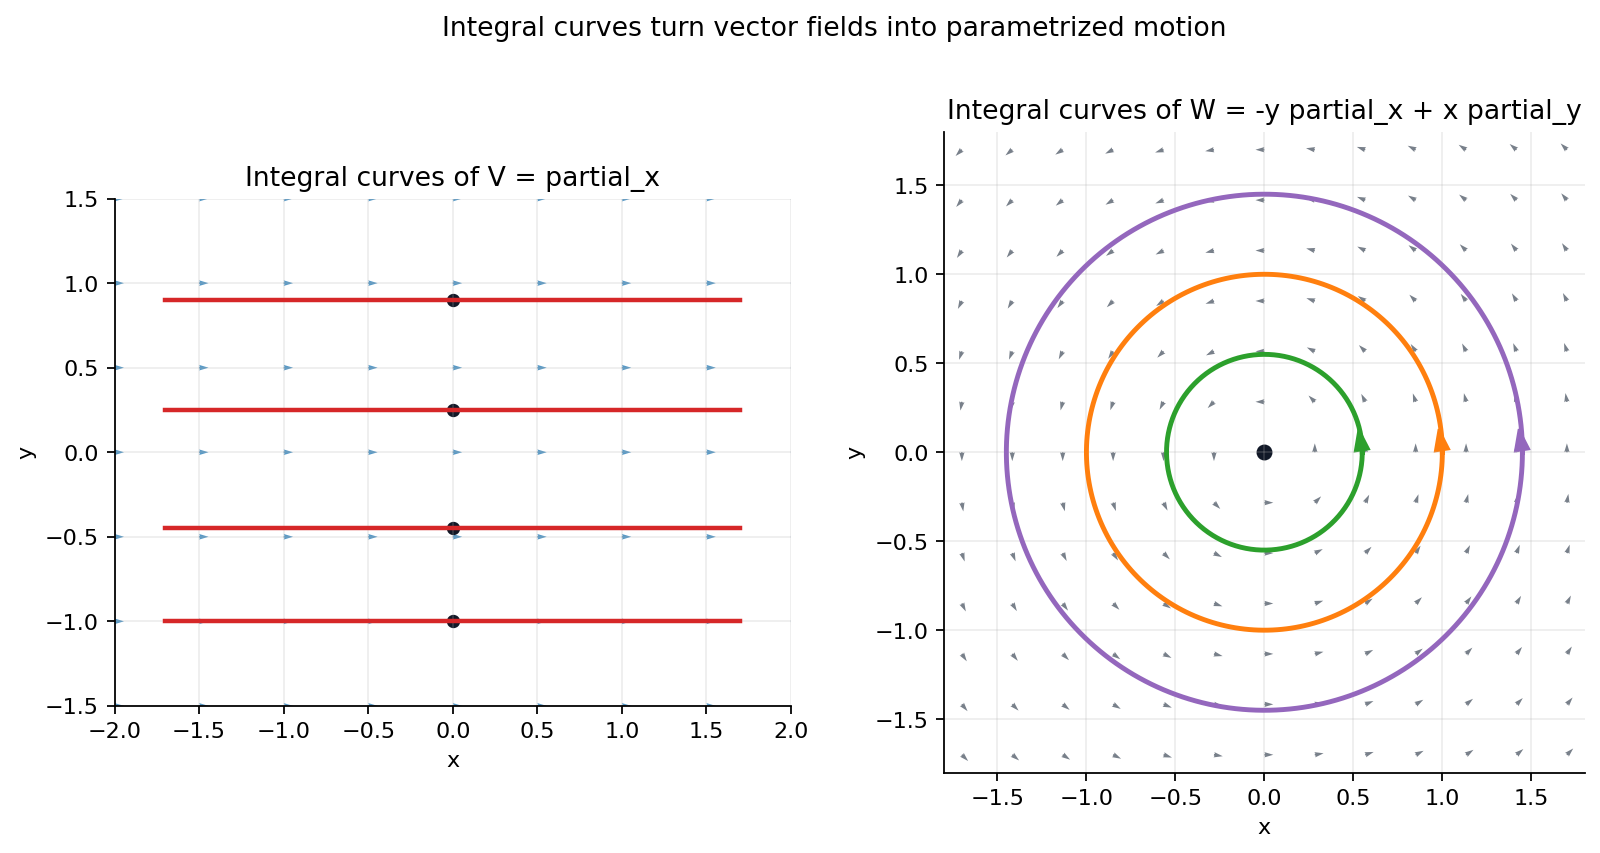

In [4]:
t, a, b = sp.symbols("t a b", real=True)
gamma_line = sp.Matrix([a + t, b])
residual_line = sp.simplify(gamma_line.diff(t) - sp.Matrix([1, 0]))

gamma_circle = sp.Matrix([a * sp.cos(t) - b * sp.sin(t), a * sp.sin(t) + b * sp.cos(t)])
rotation_field_at_gamma = sp.Matrix([-gamma_circle[1], gamma_circle[0]])
residual_circle = sp.simplify(gamma_circle.diff(t) - rotation_field_at_gamma)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
ax = axes[0]
xs = np.linspace(-2.0, 2.0, 9)
ys = np.linspace(-1.5, 1.5, 7)
quiver_field(ax, xs, ys, lambda X, Y: (np.ones_like(X), np.zeros_like(Y)), color="#1f77b4", scale=18)
tt = np.linspace(-1.7, 1.7, 160)
for y0 in [-1.0, -0.45, 0.25, 0.9]:
    ax.plot(tt, np.full_like(tt, y0), color="#d62728", lw=2)
    ax.scatter([0], [y0], s=25, color="#111827")
ax.set_title("Integral curves of V = partial_x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, 1.5)

ax = axes[1]
grid = np.linspace(-1.7, 1.7, 13)
quiver_field(ax, grid, grid, lambda X, Y: (-Y, X), color="#4b5563", scale=20)
theta = np.linspace(0, 2 * np.pi, 240)
for r, color in [(0.55, "#2ca02c"), (1.0, "#ff7f0e"), (1.45, "#9467bd")]:
    ax.plot(r * np.cos(theta), r * np.sin(theta), color=color, lw=2.2)
    ax.arrow(r, 0, -0.02, 0.13, head_width=0.08, color=color, length_includes_head=True)
ax.scatter([0], [0], s=38, color="#111827")
ax.set_title("Integral curves of W = -y partial_x + x partial_y")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
fig.suptitle("Integral curves turn vector fields into parametrized motion", y=1.02)
integral_curve_path = remember(save_matplotlib(fig, FIGURES / "integral-curves-translation-rotation.png"))
plt.close(fig)

integral_checks = {
    "translation_residual": [str(item) for item in residual_line],
    "rotation_residual": [str(sp.simplify(item)) for item in residual_circle],
    "translation_residual_zero": all(sp.simplify(item) == 0 for item in residual_line),
    "rotation_residual_zero": all(sp.simplify(item) == 0 for item in residual_circle),
}
integral_check_path = remember(save_json(integral_checks, CHECKS / "integral-curve-residuals.json"))
CHECK_RESULTS.update({
    "integral_translation_residual_zero": integral_checks["translation_residual_zero"],
    "integral_rotation_residual_zero": integral_checks["rotation_residual_zero"],
})
display_artifact(integral_curve_path, width=900)


## Maximal Flows and Flow Domains

A local solution is not the same thing as a global action. The vector field `x^2 partial_x` on the line has the explicit solution `phi(t, x0) = x0 / (1 - t x0)`, so the maximal interval through `t = 0` stops at the blow-up time. A different obstruction occurs on a punctured plane: the harmless-looking translation field can run into the missing origin.

The lesson is that the flow domain is part of the object. A local flow has open slices `M_t`, and `phi_t` is a diffeomorphism from `M_t` to `M_-t`.


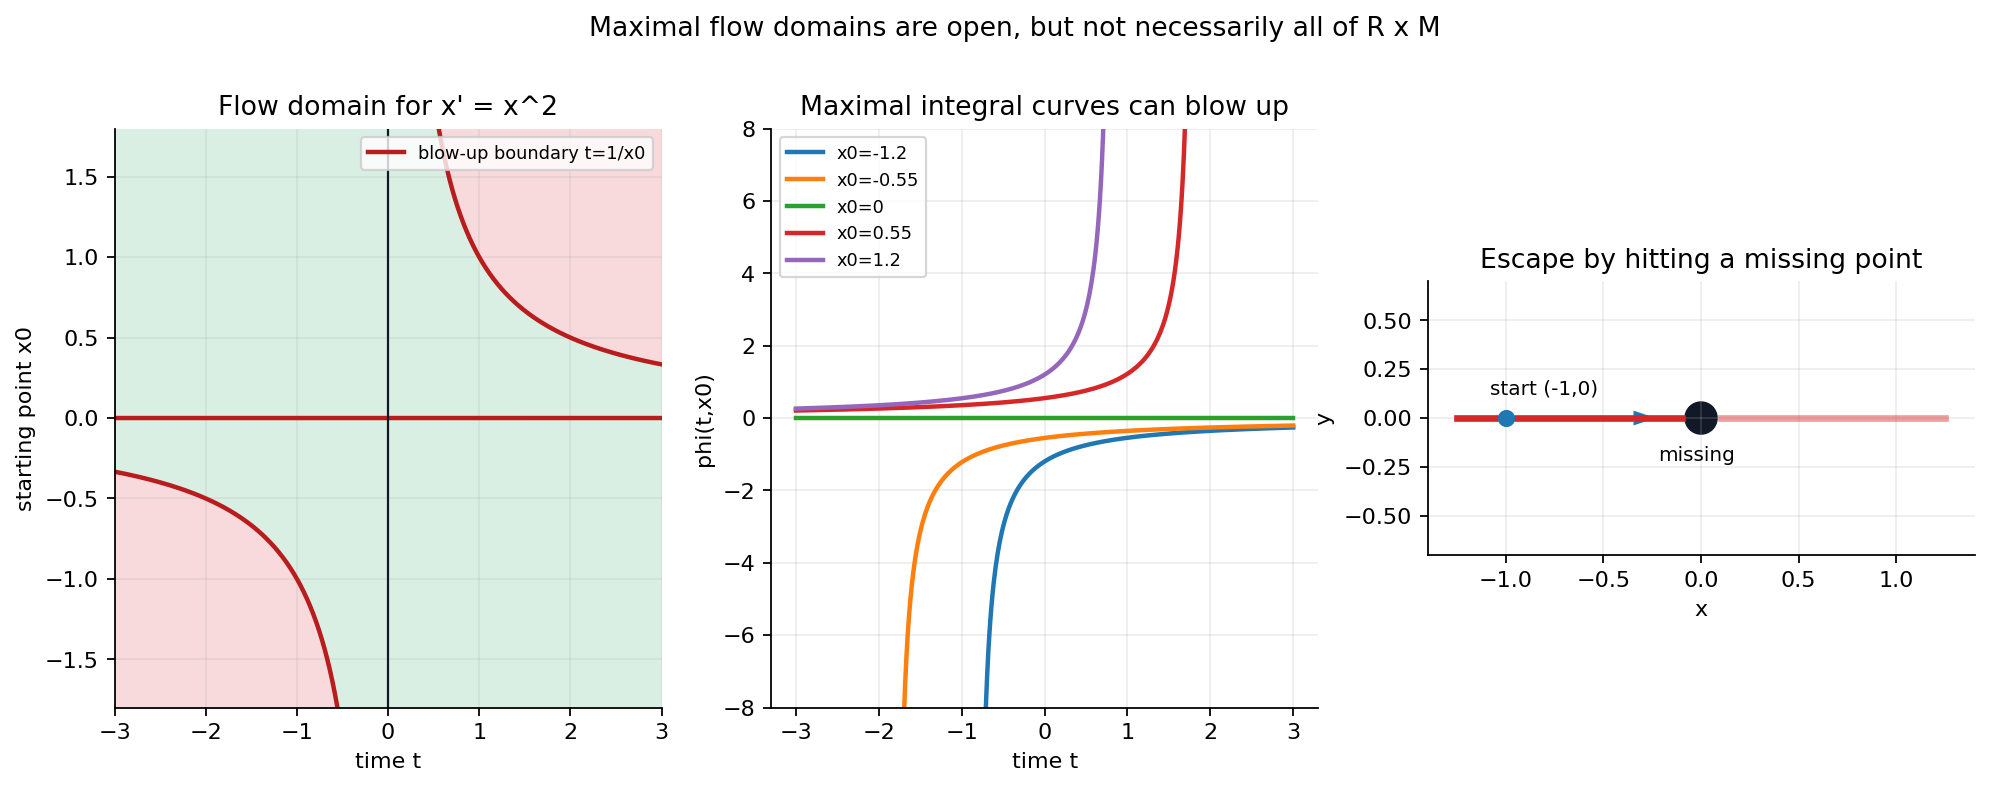

In [5]:
x, s = sp.symbols("x s", real=True)
phi = lambda tau, z: sp.simplify(z / (1 - tau * z))
flow_law_residual = sp.simplify(phi(s, phi(t, x)) - phi(t + s, x))
inverse_residual = sp.simplify(phi(-t, phi(t, x)) - x)

x0_vals = [-1.2, -0.55, 0.0, 0.55, 1.2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.7))

ax = axes[0]
x0_grid = np.linspace(-1.8, 1.8, 420)
t_grid = np.linspace(-3.0, 3.0, 420)
T, X0 = np.meshgrid(t_grid, x0_grid)
domain_mask = 1 - T * X0 > 0
ax.contourf(T, X0, domain_mask.astype(float), levels=[-0.1, 0.5, 1.1], colors=["#f8d7da", "#d8efe2"], alpha=0.95)
singular = np.where(np.abs(x0_grid) > 1e-6, 1 / x0_grid, np.nan)
ax.plot(singular, x0_grid, color="#b91c1c", lw=2, label="blow-up boundary t=1/x0")
ax.axvline(0, color="#111827", lw=1)
ax.set_xlim(-3, 3)
ax.set_ylim(-1.8, 1.8)
ax.set_xlabel("time t")
ax.set_ylabel("starting point x0")
ax.set_title("Flow domain for x' = x^2")
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
for x0 in x0_vals:
    if x0 == 0:
        times = np.linspace(-3, 3, 300)
    elif x0 > 0:
        times = np.linspace(-3, 1 / x0 - 0.04, 300)
    else:
        times = np.linspace(1 / x0 + 0.04, 3, 300)
    vals = x0 / (1 - times * x0)
    ax.plot(times, vals, lw=2, label=f"x0={x0:g}")
ax.set_ylim(-8, 8)
ax.set_xlabel("time t")
ax.set_ylabel("phi(t,x0)")
ax.set_title("Maximal integral curves can blow up")
ax.legend(fontsize=8)

ax = axes[2]
circle = Circle((0, 0), 0.08, color="#111827")
ax.add_patch(circle)
yline = 0.0
ax.plot([-1.25, -0.1], [yline, yline], color="#d62728", lw=3)
ax.plot([0.1, 1.25], [yline, yline], color="#d62728", lw=3, alpha=0.45)
ax.scatter([-1], [0], color="#1f77b4", s=45, zorder=3)
ax.arrow(-1, 0, 0.75, 0, head_width=0.06, length_includes_head=True, color="#1f77b4")
ax.text(-1.08, 0.12, "start (-1,0)", fontsize=9)
ax.text(-0.22, -0.22, "missing", fontsize=9)
ax.set_title("Escape by hitting a missing point")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-0.7, 0.7)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")

fig.suptitle("Maximal flow domains are open, but not necessarily all of R x M", y=1.03)
maximal_domain_path = remember(save_matplotlib(fig, FIGURES / "maximal-flow-domains-and-escape.png"))
plt.close(fig)

sample_p = sp.Rational(3, 4)
sample_shift = sp.Rational(1, 2)
endpoint_before = 1 / sample_p
endpoint_after = 1 / phi(sample_shift, sample_p)
shifted_endpoint = sp.simplify(endpoint_before - sample_shift)
maximal_checks = {
    "flow_law_residual": str(flow_law_residual),
    "inverse_residual": str(inverse_residual),
    "domain_inequality": "1 - t*x0 > 0",
    "sample_domain_endpoint_after_flow": str(sp.simplify(endpoint_after)),
    "sample_shifted_endpoint": str(shifted_endpoint),
    "shifted_interval_endpoint_matches": sp.simplify(endpoint_after - shifted_endpoint) == 0,
    "punctured_plane_translation_hits_removed_origin_at_t": 1,
}
maximal_check_path = remember(save_json(maximal_checks, CHECKS / "maximal-flow-domain-checks.json"))
CHECK_RESULTS.update({
    "maximal_flow_law_zero": flow_law_residual == 0,
    "maximal_inverse_zero": inverse_residual == 0,
    "maximal_shifted_interval_matches": maximal_checks["shifted_interval_endpoint_matches"],
})
display_artifact(maximal_domain_path, width=980)


## Flowouts and Canonical Coordinates

A flowout starts with a submanifold `S` and follows the vector field for time `t`. If `V` is nowhere tangent to `S`, the map `(t, s) -> phi_t(X(s))` has full rank near `S`. For a hypersurface this gives local coordinates. In these coordinates the vector field itself becomes the coordinate field `partial_t`.

The rotation example below starts from the positive `x`-axis and flows under `W = -y partial_x + x partial_y`. The flowout map is `(t, s) -> (s cos t, s sin t)`. Near `s > 0`, its inverse is polar angle and radius, and the field is straightened.


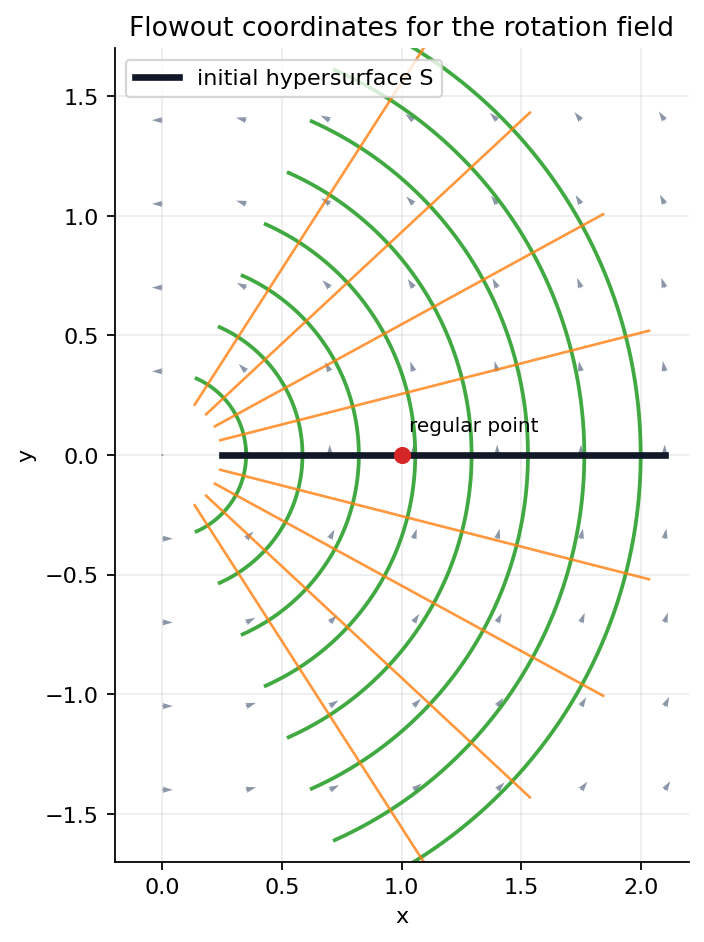

In [6]:
tt = np.linspace(-1.15, 1.15, 100)
ss = np.linspace(0.35, 2.0, 8)
fig, ax = plt.subplots(figsize=(7.4, 6.6))
grid = np.linspace(-2.1, 2.1, 13)
quiver_field(ax, grid, grid, lambda X, Y: (-Y, X), color="#64748b", scale=23)
for s0 in ss:
    ax.plot(s0 * np.cos(tt), s0 * np.sin(tt), color="#2ca02c", lw=1.7, alpha=0.9)
for t0 in np.linspace(-1.0, 1.0, 9):
    ray_s = np.linspace(0.25, 2.1, 120)
    ax.plot(ray_s * np.cos(t0), ray_s * np.sin(t0), color="#ff7f0e", lw=1.2, alpha=0.8)
ax.plot([0.25, 2.1], [0, 0], color="#111827", lw=3, label="initial hypersurface S")
ax.scatter([1], [0], color="#d62728", s=45, zorder=4)
ax.text(1.03, 0.1, "regular point", fontsize=9)
ax.set_title("Flowout coordinates for the rotation field")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_xlim(-0.2, 2.2)
ax.set_ylim(-1.7, 1.7)
ax.legend(loc="upper left")
flowout_path = remember(save_matplotlib(fig, FIGURES / "flowout-canonical-coordinates.png"))
plt.close(fig)

Phi = sp.Matrix([s * sp.cos(t), s * sp.sin(t)])
jac = Phi.jacobian([t, s])
jac_det = sp.simplify(jac.det())
push_dt = jac[:, 0]
rotation_at_phi = sp.Matrix([-Phi[1], Phi[0]])
flowout_checks = {
    "flowout_map": "(t,s) -> (s*cos(t), s*sin(t))",
    "jacobian_determinant": str(jac_det),
    "nonzero_for_positive_s": True,
    "pushforward_partial_t_minus_W": [str(sp.simplify(v)) for v in push_dt - rotation_at_phi],
    "pushforward_check_zero": all(sp.simplify(v) == 0 for v in push_dt - rotation_at_phi),
}
flowout_check_path = remember(save_json(flowout_checks, CHECKS / "flowout-canonical-coordinate-checks.json"))
CHECK_RESULTS.update({
    "flowout_jacobian_nonzero_on_positive_s": flowout_checks["nonzero_for_positive_s"],
    "flowout_pushforward_zero": flowout_checks["pushforward_check_zero"],
})
display_artifact(flowout_path, width=760)


## Boundary Behavior: Tangent Fields, Inward Fields, and Collars

On a manifold with boundary, not every vector field has a two-sided flow that stays in the manifold. The boundary normal component tells the story. A tangent field has zero normal component and preserves the boundary. An inward-pointing field gives a one-sided flowout from the boundary, which is the local model behind collar neighborhoods. An outward field immediately leaves the half-plane if started at the boundary.


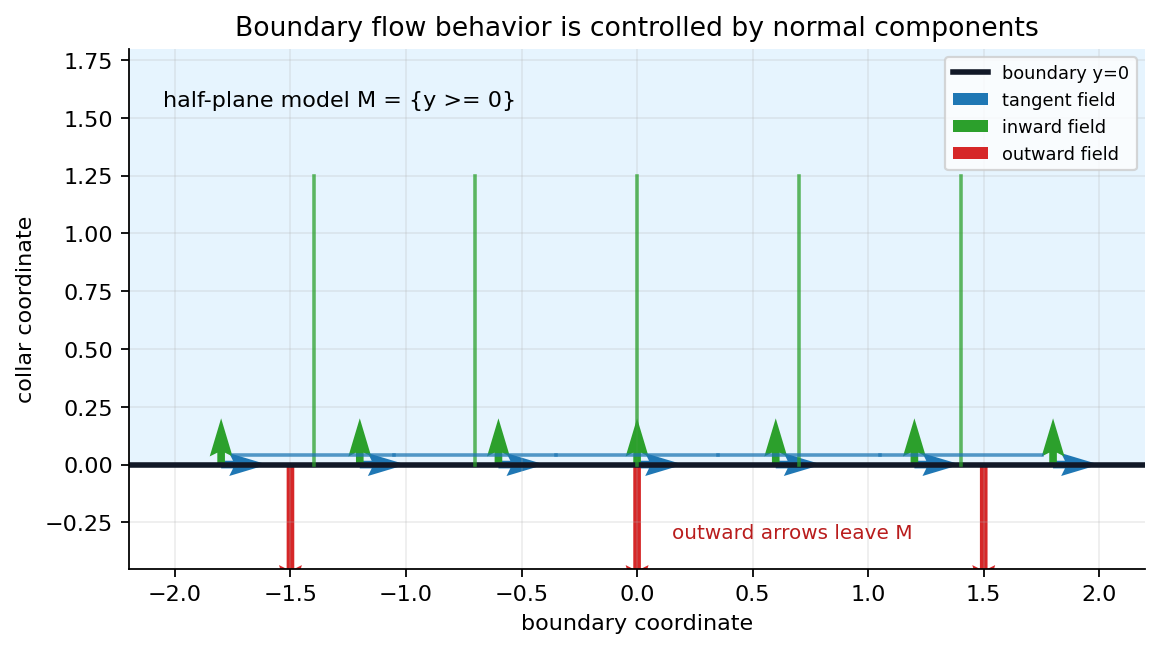

In [7]:
fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.add_patch(Rectangle((-2.2, 0), 4.4, 1.8, facecolor="#e0f2fe", edgecolor="none", alpha=0.8))
ax.plot([-2.2, 2.2], [0, 0], color="#111827", lw=2.5, label="boundary y=0")
boundary_x = np.linspace(-1.8, 1.8, 7)
ax.quiver(boundary_x, np.zeros_like(boundary_x), np.ones_like(boundary_x), np.zeros_like(boundary_x),
          angles="xy", scale_units="xy", scale=5, color="#1f77b4", label="tangent field")
ax.quiver(boundary_x, np.zeros_like(boundary_x), np.zeros_like(boundary_x), np.ones_like(boundary_x),
          angles="xy", scale_units="xy", scale=5, color="#2ca02c", label="inward field")
ax.quiver([-1.5, 0, 1.5], [0, 0, 0], [0, 0, 0], [-0.6, -0.6, -0.6],
          angles="xy", scale_units="xy", scale=1, color="#d62728", label="outward field")
for x0 in [-1.4, -0.7, 0.0, 0.7, 1.4]:
    ax.plot([x0, x0], [0, 1.25], color="#2ca02c", lw=1.6, alpha=0.75)
    ax.plot([x0 - 0.35, x0 + 0.35], [0.04, 0.04], color="#1f77b4", lw=1.6, alpha=0.75)
ax.text(-2.05, 1.55, "half-plane model M = {y >= 0}", fontsize=10)
ax.text(0.15, -0.32, "outward arrows leave M", color="#b91c1c", fontsize=9)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-0.45, 1.8)
ax.set_aspect("equal")
ax.set_xlabel("boundary coordinate")
ax.set_ylabel("collar coordinate")
ax.set_title("Boundary flow behavior is controlled by normal components")
ax.legend(loc="upper right", fontsize=8)
boundary_path = remember(save_matplotlib(fig, FIGURES / "boundary-flow-behavior.png"))
plt.close(fig)

boundary_checks = {
    "inward_normal": [0, 1],
    "tangent_field_dot_inward_normal": 0,
    "inward_field_dot_inward_normal": 1,
    "outward_field_dot_inward_normal": -1,
    "tangent_field_preserves_boundary_y_coordinate": True,
    "inward_field_defines_one_sided_collar": True,
}
boundary_check_path = remember(save_json(boundary_checks, CHECKS / "boundary-flow-behavior-checks.json"))
CHECK_RESULTS.update({
    "boundary_tangent_normal_zero": boundary_checks["tangent_field_dot_inward_normal"] == 0,
    "boundary_inward_positive": boundary_checks["inward_field_dot_inward_normal"] > 0,
    "boundary_outward_negative": boundary_checks["outward_field_dot_inward_normal"] < 0,
})
display_artifact(boundary_path, width=800)


## Lie Derivatives: Compare Vectors After Pulling Back

The derivative of a function along a vector is direct because a tangent vector acts on functions. The derivative of one vector field along another is subtler: nearby vector values live in different tangent spaces. The flow of `V` solves this by moving `W` back to the original point before differentiating. For `V = partial_x` and `W = x partial_y`, the pullback comparison changes by `t partial_y`, so `L_V W = partial_y`. The symbolic check records the identity `L_V W = [V, W]` for this model.


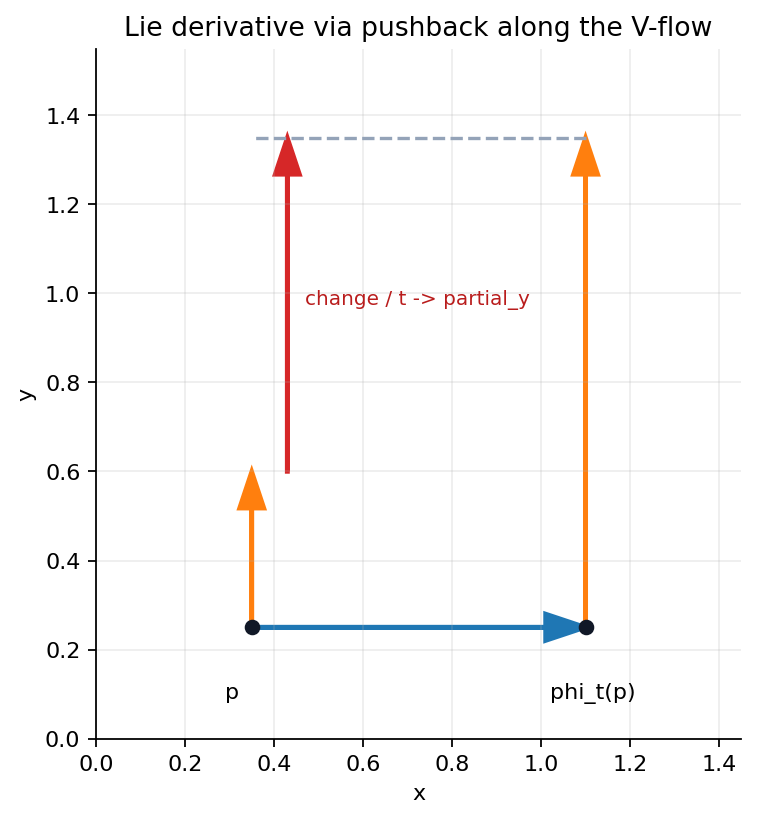

In [8]:
base = np.array([0.35, 0.25])
tau = 0.75
moved = base + np.array([tau, 0.0])
W_base = np.array([0.0, base[0]])
W_moved = np.array([0.0, moved[0]])
difference = W_moved - W_base

fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.arrow(base[0], base[1], tau, 0, head_width=0.06, color="#1f77b4", length_includes_head=True, lw=2)
ax.scatter([base[0], moved[0]], [base[1], moved[1]], color="#111827", zorder=3)
ax.text(base[0] - 0.06, base[1] - 0.16, "p", fontsize=10)
ax.text(moved[0] - 0.08, moved[1] - 0.16, "phi_t(p)", fontsize=10)
ax.arrow(base[0], base[1], W_base[0], W_base[1], head_width=0.055, color="#ff7f0e", length_includes_head=True, lw=2)
ax.arrow(moved[0], moved[1], W_moved[0], W_moved[1], head_width=0.055, color="#ff7f0e", length_includes_head=True, lw=2)
ax.arrow(base[0] + 0.08, base[1] + W_base[1], difference[0], difference[1],
         head_width=0.055, color="#d62728", length_includes_head=True, lw=2)
ax.plot([moved[0], base[0]], [moved[1] + W_moved[1], base[1] + W_moved[1]], color="#94a3b8", lw=1.5, ls="--")
ax.text(base[0] + 0.12, base[1] + W_base[1] + difference[1] / 2, "change / t -> partial_y", color="#b91c1c", fontsize=9)
ax.set_xlim(0, 1.45)
ax.set_ylim(0, 1.55)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Lie derivative via pushback along the V-flow")
lie_path = remember(save_matplotlib(fig, FIGURES / "lie-derivative-pushback.png"))
plt.close(fig)

x_sym, y_sym = sp.symbols("x y", real=True)
bracket_vw = bracket_components((sp.Integer(1), sp.Integer(0)), (sp.Integer(0), x_sym))
finite_difference = sp.Matrix([0, sp.simplify(((x_sym + t) - x_sym) / t)])
lie_checks = {
    "bracket_[partial_x_xpartial_y]": [str(v) for v in bracket_vw],
    "finite_difference_limit": [str(sp.limit(v, t, 0)) for v in finite_difference],
    "lie_equals_bracket": bracket_vw == sp.Matrix([0, 1]),
}
lie_check_path = remember(save_json(lie_checks, CHECKS / "lie-derivative-bracket-checks.json"))
CHECK_RESULTS["lie_derivative_equals_bracket_in_model"] = lie_checks["lie_equals_bracket"]
display_artifact(lie_path, width=760)


## Commuting Fields: Flow Squares Close Exactly When the Bracket Vanishes

Two fields commute when applying them as differential operators in either order gives the same result. The flow version is more geometric: move for time `t` along one field and for time `s` along the other. If the fields commute, the two paths land at the same point. If the bracket is nonzero, the square opens by a second-order gap.


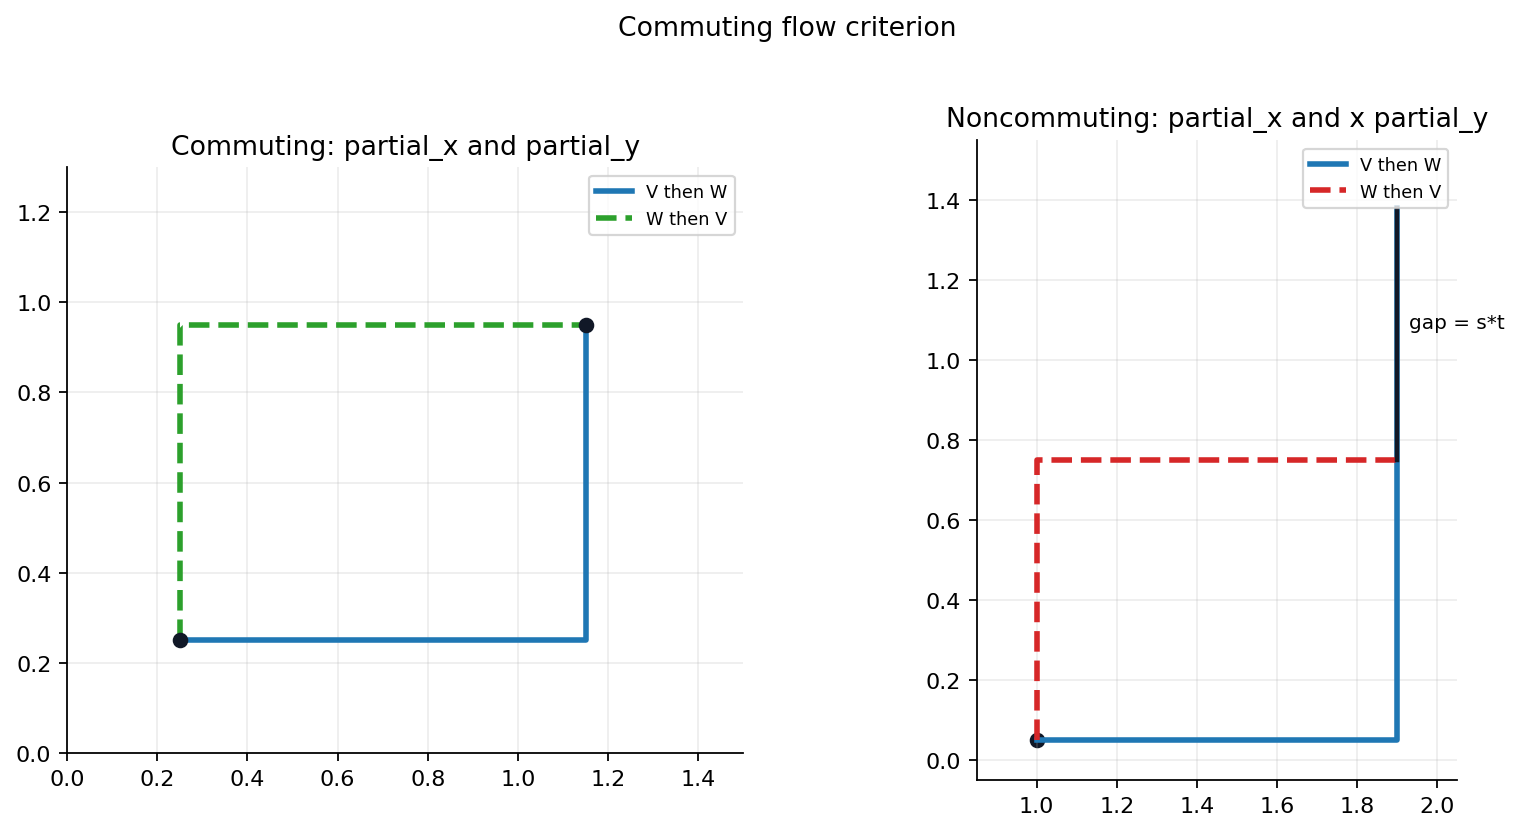

In [9]:
p0 = np.array([0.25, 0.25])
step_t = 0.9
step_s = 0.7

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
ax = axes[0]
A = p0
B = A + np.array([step_t, 0])
C = B + np.array([0, step_s])
D = A + np.array([0, step_s])
ax.plot([A[0], B[0], C[0]], [A[1], B[1], C[1]], color="#1f77b4", lw=2.5, label="V then W")
ax.plot([A[0], D[0], C[0]], [A[1], D[1], C[1]], color="#2ca02c", lw=2.5, ls="--", label="W then V")
ax.scatter([A[0], C[0]], [A[1], C[1]], color="#111827", zorder=3)
ax.set_title("Commuting: partial_x and partial_y")
ax.set_aspect("equal")
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.3)
ax.legend(fontsize=8)

ax = axes[1]
A = np.array([1.0, 0.05])
V_then_W_mid = A + np.array([step_t, 0])
V_then_W_end = V_then_W_mid + np.array([0, step_s * V_then_W_mid[0]])
W_then_V_mid = A + np.array([0, step_s * A[0]])
W_then_V_end = W_then_V_mid + np.array([step_t, 0])
ax.plot([A[0], V_then_W_mid[0], V_then_W_end[0]], [A[1], V_then_W_mid[1], V_then_W_end[1]],
        color="#1f77b4", lw=2.5, label="V then W")
ax.plot([A[0], W_then_V_mid[0], W_then_V_end[0]], [A[1], W_then_V_mid[1], W_then_V_end[1]],
        color="#d62728", lw=2.5, ls="--", label="W then V")
ax.plot([W_then_V_end[0], V_then_W_end[0]], [W_then_V_end[1], V_then_W_end[1]], color="#111827", lw=2)
ax.text(1.93, 1.08, "gap = s*t", fontsize=9)
ax.scatter([A[0]], [A[1]], color="#111827")
ax.set_title("Noncommuting: partial_x and x partial_y")
ax.set_aspect("equal")
ax.set_xlim(0.85, 2.05)
ax.set_ylim(-0.05, 1.55)
ax.legend(fontsize=8)
fig.suptitle("Commuting flow criterion", y=1.03)
commuting_path = remember(save_matplotlib(fig, FIGURES / "commuting-flow-squares.png"))
plt.close(fig)

bracket_commuting = bracket_components((sp.Integer(1), sp.Integer(0)), (sp.Integer(0), sp.Integer(1)))
bracket_noncommuting = bracket_components((sp.Integer(1), sp.Integer(0)), (sp.Integer(0), x_sym))
s_flow, t_flow = sp.symbols("s_flow t_flow", real=True)
endpoint_gap = sp.Matrix([0, s_flow * t_flow])
commuting_checks = {
    "bracket_partial_x_partial_y": [str(v) for v in bracket_commuting],
    "bracket_partial_x_xpartial_y": [str(v) for v in bracket_noncommuting],
    "noncommuting_endpoint_gap": [str(v) for v in endpoint_gap],
    "commuting_bracket_zero": bracket_commuting == sp.Matrix([0, 0]),
    "noncommuting_bracket_nonzero": bracket_noncommuting != sp.Matrix([0, 0]),
}
commuting_check_path = remember(save_json(commuting_checks, CHECKS / "commuting-flow-square-checks.json"))
CHECK_RESULTS.update({
    "commuting_bracket_zero": commuting_checks["commuting_bracket_zero"],
    "noncommuting_bracket_nonzero": commuting_checks["noncommuting_bracket_nonzero"],
})
display_artifact(commuting_path, width=920)


## Time-Dependent Vector Fields

An autonomous flow only needs elapsed time. A time-dependent field needs both the current time and the starting time. The model `V(t, x) = x/t` on `t > 0` has flow `Phi(t, t0, x0) = (t/t0) x0`. The cocycle law uses a middle time:

`Phi(t2, t1, Phi(t1, t0, x0)) = Phi(t2, t0, x0)`.


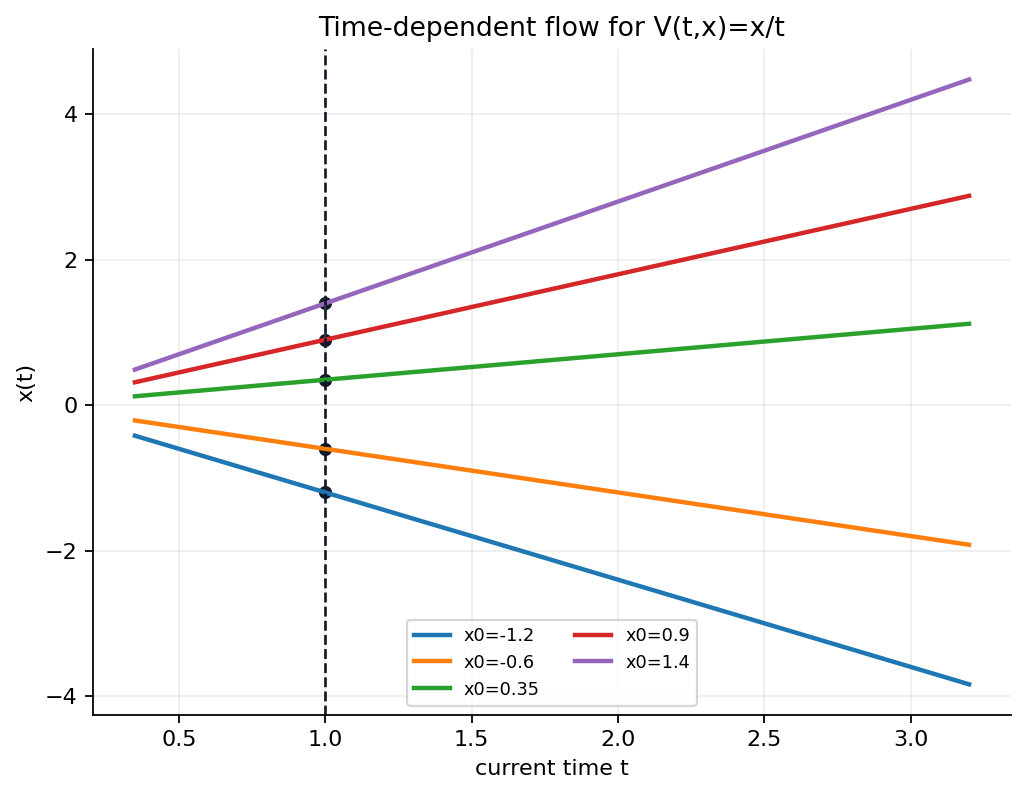

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [10]:
fig, ax = plt.subplots(figsize=(7.4, 5.4))
times = np.linspace(0.35, 3.2, 240)
t0_val = 1.0
for x0 in [-1.2, -0.6, 0.35, 0.9, 1.4]:
    ax.plot(times, times / t0_val * x0, lw=2, label=f"x0={x0:g}")
    ax.scatter([t0_val], [x0], s=24, color="#111827")
ax.axvline(t0_val, color="#111827", lw=1.2, ls="--")
ax.set_xlabel("current time t")
ax.set_ylabel("x(t)")
ax.set_title("Time-dependent flow for V(t,x)=x/t")
ax.legend(fontsize=8, ncol=2)
time_dep_path = remember(save_matplotlib(fig, FIGURES / "time-dependent-flow-scaling.png"))
plt.close(fig)

surface_t0 = np.linspace(0.5, 2.0, 35)
surface_t = np.linspace(0.5, 3.0, 45)
T0, T1 = np.meshgrid(surface_t0, surface_t)
X0 = 1.0
X1 = T1 / T0 * X0
plotly_fig = go.Figure(data=[
    go.Surface(x=T0, y=T1, z=X1, colorscale="Viridis", opacity=0.88, showscale=True)
])
plotly_fig.update_layout(
    title="Time-dependent scaling flow: Phi(t,t0,1)=t/t0",
    scene=dict(xaxis_title="start time t0", yaxis_title="current time t", zaxis_title="position"),
    margin=dict(l=0, r=0, t=45, b=0),
)
time_dep_html_path = remember(save_plotly_self_contained(plotly_fig, HTML / "time-dependent-flow-scaling.html"))

t0_sym, t1_sym, t2_sym, x0_sym = sp.symbols("t0 t1 t2 x0", positive=True)
Phi_td = lambda target, start, value: sp.simplify(target / start * value)
cocycle_residual = sp.simplify(Phi_td(t2_sym, t1_sym, Phi_td(t1_sym, t0_sym, x0_sym)) - Phi_td(t2_sym, t0_sym, x0_sym))
time_dep_checks = {
    "flow_formula": "Phi(t,t0,x0)=t*x0/t0 on t,t0>0",
    "cocycle_residual": str(cocycle_residual),
    "cocycle_residual_zero": cocycle_residual == 0,
}
time_dep_check_path = remember(save_json(time_dep_checks, CHECKS / "time-dependent-flow-checks.json"))
CHECK_RESULTS["time_dependent_cocycle_zero"] = time_dep_checks["cocycle_residual_zero"]
display_artifact(time_dep_path, width=760)
display_artifact(time_dep_html_path, width=820, height=560)


## First-Order PDE Characteristics

The chapter ends by turning first-order Cauchy problems into flow problems. For a linear equation `A u + b u = f`, the vector field `A` supplies characteristic curves in the base manifold, and the unknown function satisfies an ODE along each curve. For a quasilinear equation, the dependent variable becomes a new coordinate; the graph of the solution is built as a flowout in `(x, y, z)` space.

The linear model below uses the rotation field `A = -y partial_x + x partial_y` and solves `A u = x` with initial values on the positive `x`-axis. The solution `u = sqrt(x^2 + y^2) + y` has the right initial value near that axis and has PDE residual zero. The quasilinear model uses `(u+1)u_x + u_y = 0`, `u(x,0)=x`; its characteristic flowout gives `u=(x-y)/(1+y)` on the side where `y > -1`.


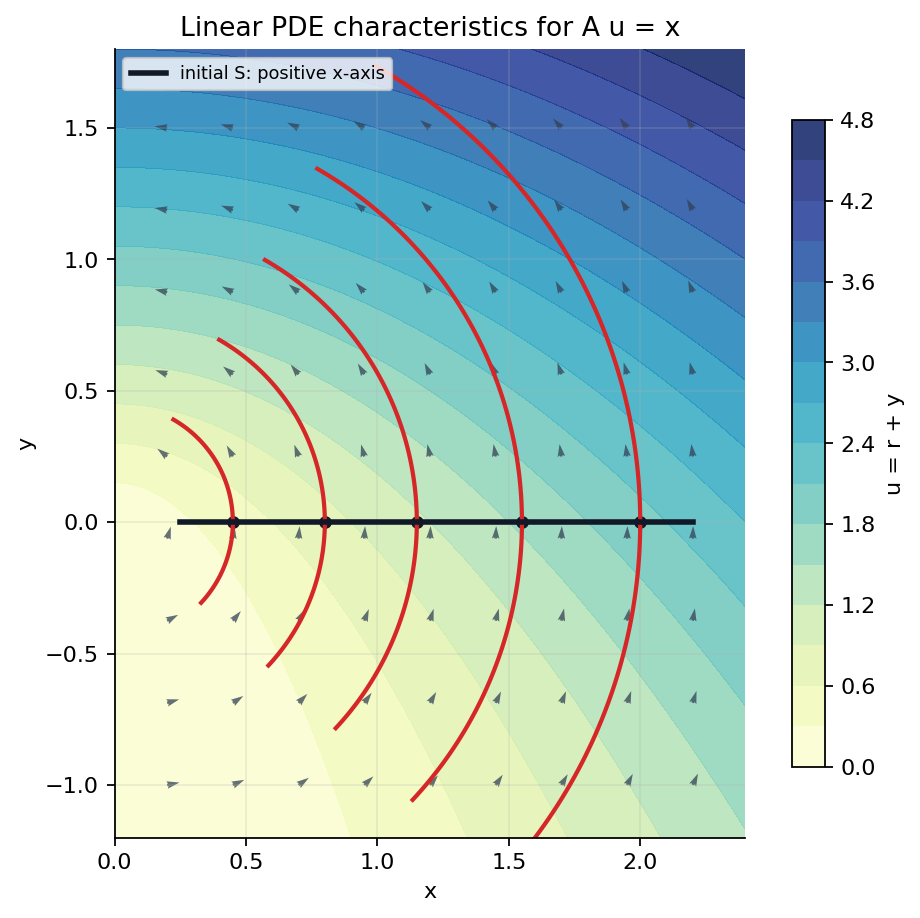

In [11]:
fig, ax = plt.subplots(figsize=(7.6, 6.4))
xs = np.linspace(0.0, 2.4, 160)
ys = np.linspace(-1.2, 1.8, 160)
X, Y = np.meshgrid(xs, ys)
R = np.sqrt(X**2 + Y**2)
U_solution = R + Y
contour = ax.contourf(X, Y, U_solution, levels=18, cmap="YlGnBu", alpha=0.86)
theta = np.linspace(-0.75, 1.05, 120)
for s0 in [0.45, 0.8, 1.15, 1.55, 2.0]:
    ax.plot(s0 * np.cos(theta), s0 * np.sin(theta), color="#d62728", lw=1.9)
    ax.scatter([s0], [0], color="#111827", s=22)
ax.plot([0.25, 2.2], [0, 0], color="#111827", lw=2.5, label="initial S: positive x-axis")
quiver_field(ax, np.linspace(0.2, 2.2, 9), np.linspace(-1.0, 1.5, 9), lambda X, Y: (-Y, X), color="#334155", scale=21)
ax.set_xlim(0, 2.4)
ax.set_ylim(-1.2, 1.8)
ax.set_aspect("equal")
ax.set_title("Linear PDE characteristics for A u = x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(contour, ax=ax, shrink=0.82, label="u = r + y")
linear_pde_path = remember(save_matplotlib(fig, FIGURES / "linear-pde-characteristics.png"))
plt.close(fig)

x_sym, y_sym = sp.symbols("x y", real=True)
r_sym = sp.sqrt(x_sym**2 + y_sym**2)
u_linear = r_sym + y_sym
linear_residual = sp.simplify((-y_sym) * sp.diff(u_linear, x_sym) + x_sym * sp.diff(u_linear, y_sym) - x_sym)
s_pos = sp.symbols("s_pos", positive=True)
noncharacteristic_det = sp.Matrix([[1, 0], [0, s_pos]]).det()

s_vals = np.linspace(-1.3, 1.3, 35)
t_vals = np.linspace(-0.85, 1.25, 45)
S_grid, T_grid = np.meshgrid(s_vals, t_vals)
Xq = S_grid + T_grid * (S_grid + 1)
Yq = T_grid
Zq = S_grid
qfig = go.Figure(data=[
    go.Surface(x=Xq, y=Yq, z=Zq, colorscale="Plasma", opacity=0.86, name="solution graph"),
    go.Scatter3d(x=s_vals, y=np.zeros_like(s_vals), z=s_vals, mode="lines", line=dict(color="black", width=6), name="initial graph"),
])
qfig.update_layout(
    title="Quasilinear characteristic flowout for (u+1)u_x + u_y = 0",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z = u"),
    margin=dict(l=0, r=0, t=50, b=0),
)
quasilinear_html_path = remember(save_plotly_self_contained(qfig, HTML / "quasilinear-characteristic-flowout.html"))

u_quasi = (x_sym - y_sym) / (1 + y_sym)
quasi_residual = sp.simplify((u_quasi + 1) * sp.diff(u_quasi, x_sym) + sp.diff(u_quasi, y_sym))
quasi_initial = sp.simplify(u_quasi.subs(y_sym, 0) - x_sym)
jac_projection = sp.Matrix([
    [sp.diff(s + t * (s + 1), t), sp.diff(s + t * (s + 1), s)],
    [sp.diff(t, t), sp.diff(t, s)],
]).det()
pde_checks = {
    "linear_solution": "u=sqrt(x^2+y^2)+y near the positive x-axis",
    "linear_pde_residual": str(linear_residual),
    "linear_noncharacteristic_determinant_on_S": str(noncharacteristic_det),
    "linear_residual_zero": linear_residual == 0,
    "quasilinear_solution": "u=(x-y)/(1+y), valid where y>-1",
    "quasilinear_pde_residual": str(quasi_residual),
    "quasilinear_initial_residual": str(quasi_initial),
    "quasilinear_projection_jacobian": str(sp.simplify(jac_projection)),
    "quasilinear_residual_zero": quasi_residual == 0,
    "quasilinear_initial_zero": quasi_initial == 0,
    "projection_jacobian_nonzero_near_initial_surface": sp.simplify(jac_projection.subs(t, 0)) != 0,
}
pde_check_path = remember(save_json(pde_checks, CHECKS / "pde-characteristic-checks.json"))
CHECK_RESULTS.update({
    "linear_pde_residual_zero": pde_checks["linear_residual_zero"],
    "quasilinear_pde_residual_zero": pde_checks["quasilinear_residual_zero"],
    "quasilinear_initial_zero": pde_checks["quasilinear_initial_zero"],
    "quasilinear_projection_regular_near_S": pde_checks["projection_jacobian_nonzero_near_initial_surface"],
})
display_artifact(linear_pde_path, width=760)
display_artifact(quasilinear_html_path, width=820, height=560)


## Applied Lab

Use the cells above as a controlled perturbation lab.

1. In the maximal-domain model, replace `x^2 partial_x` by `-x^2 partial_x`. Predict how the green domain in the `(t, x0)` plane flips, then verify the new blow-up boundary.
2. In the flowout model, let the initial submanifold include `s = 0`. The Jacobian determinant says exactly why the polar flowout stops being a coordinate chart at the singular point.
3. In the boundary model, change the tangent field to `(1, epsilon)`. A positive `epsilon` points inward, a negative one points outward, and `epsilon = 0` is the boundary-preserving case.
4. In the commuting-square model, shrink both times by a factor of ten. The endpoint gap becomes small, but it is still governed by the same bracket.
5. In the quasilinear PDE model, watch the projection Jacobian `-(1+t)`. The graph construction is local because the projection stops being a graph when this value reaches zero.


## Computational Checks

The final cell checks both artifact integrity and mathematical invariants. It writes `checks/final_sanity.json` so that later audits can see what this chapter promised and what passed.


In [12]:
assert_artifacts(GENERATED_ARTIFACTS, min_bytes=80)

false_checks = [name for name, passed in CHECK_RESULTS.items() if not bool(passed)]
if false_checks:
    raise AssertionError(f"failed checks: {false_checks}")

image_stats = {}
try:
    from PIL import Image, ImageStat
    for path in GENERATED_ARTIFACTS:
        if Path(path).suffix.lower() == ".png":
            img = Image.open(path).convert("RGB")
            stat = ImageStat.Stat(img)
            image_stats[Path(path).name] = {
                "size": img.size,
                "max_channel_stddev": max(stat.stddev),
            }
            assert img.size[0] >= 300 and img.size[1] >= 240
            assert max(stat.stddev) > 1.0
except ImportError:
    image_stats["PIL"] = "not available"

final_report = {
    "unit": UNIT_TITLE,
    "source_span": {
        "printed_pages": "205-248",
        "pdf_pages_inspected": "223-266",
        "source_map_focus": "Integral curves, flows, flowouts, manifolds with boundary, Lie derivatives, commuting fields, time-dependent fields, and first-order PDEs.",
    },
    "artifact_count": len(GENERATED_ARTIFACTS),
    "artifacts": [path.relative_to(BOOK_ROOT).as_posix() for path in GENERATED_ARTIFACTS],
    "checks": {name: bool(value) for name, value in sorted(CHECK_RESULTS.items())},
    "image_stats": image_stats,
}
final_sanity_path = remember(save_json(final_report, CHECKS / "final_sanity.json"))
assert_artifacts([final_sanity_path], min_bytes=80)
display_artifact(final_sanity_path)
print(f"final_sanity passed: {len(GENERATED_ARTIFACTS)} artifacts checked before final_sanity.json")


`final_sanity.json`

final_sanity passed: 22 artifacts checked before final_sanity.json


## Takeaways

- An integral curve is the chart-level ODE solution whose velocity equals the vector field value.
- A flow is stronger than a family of curves: it includes a domain in `R x M`, inverse maps between time slices, and the local group law.
- Maximality records real geometric obstructions, including blow-up, missing points, and escape from compact sets.
- Flowouts turn transverse initial submanifolds into coordinate systems; at regular points they straighten the vector field.
- Boundary behavior is governed by normal components: tangent fields preserve the boundary, while inward fields build collars.
- The Lie derivative compares vector fields by pulling them into the same tangent space; in this chapter it becomes the Lie bracket.
- Commuting vector fields are detected both algebraically by `[V, W] = 0` and geometrically by commuting flows.
- Time-dependent flows need two time arguments and obey a cocycle law.
- First-order Cauchy problems become ODE problems along characteristic curves; noncharacteristic initial data is the transversality condition that makes a local graph solution possible.
